# Day 3 — Computer Vision Preprocessing with OpenCV

## Overview

This notebook focuses on image preprocessing techniques using OpenCV and TensorFlow/Keras.

The main goal is to understand how raw images are prepared before being passed to a machine learning or deep learning model.

## Learning Objectives

By the end of this notebook, I will be able to:

- Read and inspect images using OpenCV.
- Resize images to a fixed size.
- Convert images from BGR to RGB.
- Normalize pixel values.
- Build a reusable image preprocessing function.
- Apply image augmentation.
- Visualize augmented images.
- Apply model-specific preprocessing for transfer learning.

## Dataset

The dataset used in this notebook is:

**Flowers Multiclass Image Classification**

The dataset contains five different flower classes and will be used to demonstrate the complete image preprocessing pipeline.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

dataset_path = "/content/drive/MyDrive/flower_photos"

print("Dataset exists:", os.path.exists(dataset_path))

print("\nDataset contents:")
print(os.listdir(dataset_path))

Dataset exists: True

Dataset contents:
['validation', 'train', 'test']


In [5]:
# Get the class names from the training folder
classes = sorted(os.listdir(os.path.join(dataset_path, "train")))

print("Classes:")
for class_name in classes:
    print("-", class_name)

print("\nNumber of classes:", len(classes))

Classes:
- daisy
- dandelion
- roses
- sunflowers
- tulips

Number of classes: 5


In [6]:
# Count images in each class for each dataset split

splits = ["train", "validation", "test"]

for split in splits:
    print(f"\n{split.upper()}")
    print("-" * 30)

    split_path = os.path.join(dataset_path, split)

    for class_name in classes:
        class_path = os.path.join(split_path, class_name)

        # Count image files
        image_count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        print(f"{class_name}: {image_count}")


TRAIN
------------------------------
daisy: 607
dandelion: 872
roses: 615
sunflowers: 673
tulips: 773

VALIDATION
------------------------------
daisy: 16
dandelion: 16
roses: 16
sunflowers: 16
tulips: 16

TEST
------------------------------
daisy: 10
dandelion: 10
roses: 10
sunflowers: 10
tulips: 10


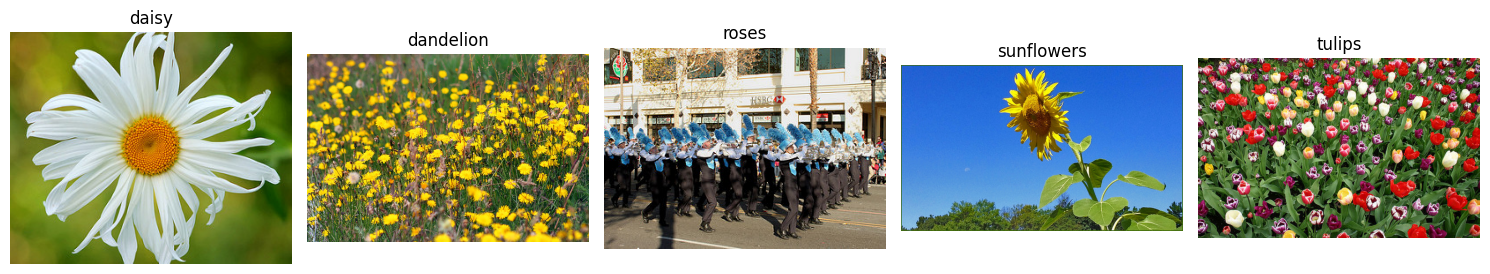

In [7]:
# Display one image from each class

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, "train", class_name)

    # Get the first image
    image_file = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ][0]

    image_path = os.path.join(class_path, image_file)

    # Read image using OpenCV
    image = cv2.imread(image_path)

    # Convert BGR to RGB for correct display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(image_rgb)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Reading an Image with OpenCV

OpenCV provides the `cv2.imread()` function to read images.

By default, OpenCV reads images in **BGR** format instead of the commonly used **RGB** format.

We will first read one image and inspect its properties.

In [8]:
# Select one image from the first class
class_name = classes[0]
class_path = os.path.join(dataset_path, "train", class_name)

image_file = [
    file for file in os.listdir(class_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
][0]

image_path = os.path.join(class_path, image_file)

# Read the image using OpenCV
image = cv2.imread(image_path)

print("Image shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())

Image shape: (263, 320, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


##  Resizing Images

Deep learning models usually require all input images to have
the same spatial dimensions.

In this step, we will resize the image to **224 × 224 pixels**.

The target size of 224 × 224 is commonly used with pretrained
models such as MobileNetV2.

In [9]:
# Resize the image to 224x224
resized_image = cv2.resize(image, (224, 224))

print("Original shape:", image.shape)
print("Resized shape:", resized_image.shape)

Original shape: (263, 320, 3)
Resized shape: (224, 224, 3)


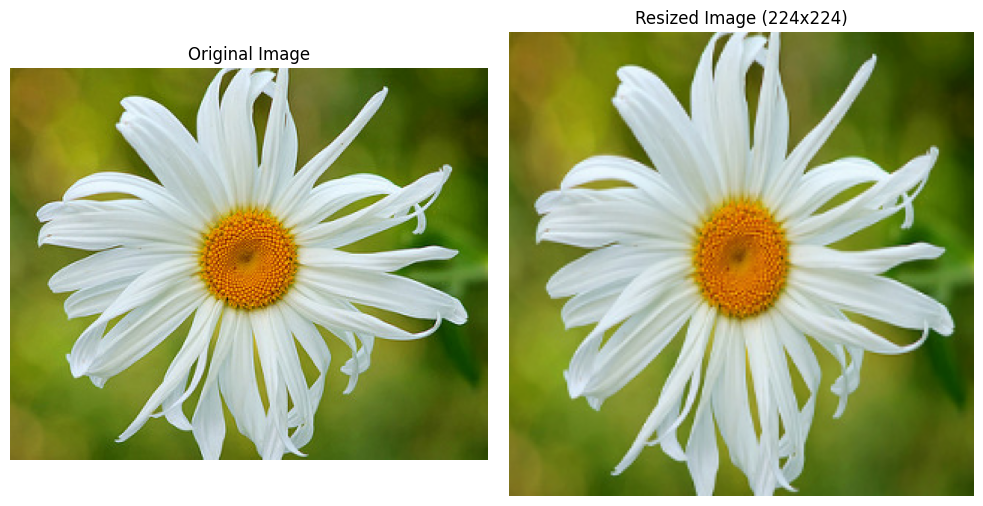

In [10]:
# Convert images from BGR to RGB for visualization
original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
resized_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

# Display both images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_rgb)
plt.title("Resized Image (224x224)")
plt.axis("off")

plt.tight_layout()
plt.show()

## BGR vs RGB

OpenCV reads images in **BGR** order:

- Blue
- Green
- Red

However, Matplotlib expects images in **RGB** order:

- Red
- Green
- Blue

If we display an OpenCV image directly using Matplotlib without
converting it, the colors may appear incorrect.

We will compare the image before and after converting it from BGR to RGB.

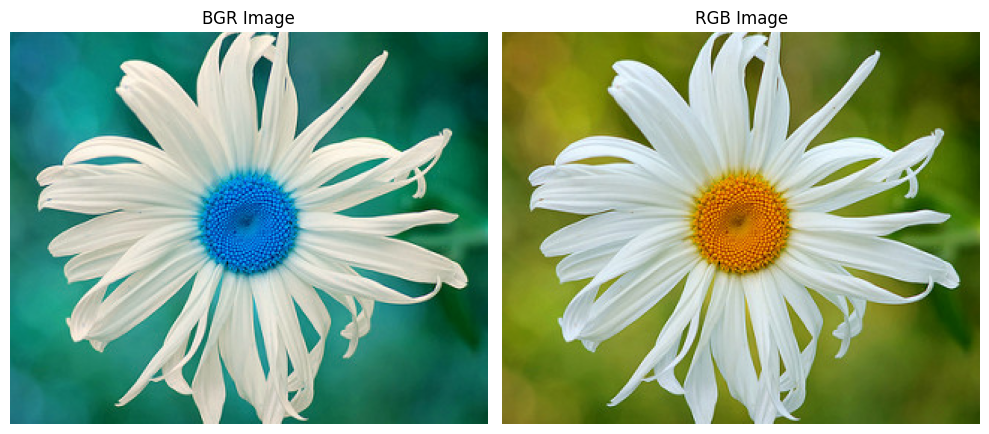

In [11]:
# Convert the image from BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

# Display BGR image directly
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("BGR Image")
plt.axis("off")

# Display correctly converted RGB image
plt.subplot(1, 2, 2)
plt.imshow(image_rgb)
plt.title("RGB Image")
plt.axis("off")

plt.tight_layout()
plt.show()

## Pixel Normalization

Images read by OpenCV usually contain pixel values between **0 and 255**.

For deep learning models, it is often useful to scale these values
to a smaller range such as **0 to 1**.

We can do this by dividing all pixel values by 255:

    normalized_image = image / 255.0

This makes the input values smaller and can help neural networks
train more effectively.

In [12]:
# Convert the image from BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Normalize pixel values from [0, 255] to [0, 1]
normalized_image = image_rgb / 255.0

print("Before normalization:")
print("Data type:", image_rgb.dtype)
print("Minimum:", image_rgb.min())
print("Maximum:", image_rgb.max())

print("\nAfter normalization:")
print("Data type:", normalized_image.dtype)
print("Minimum:", normalized_image.min())
print("Maximum:", normalized_image.max())

Before normalization:
Data type: uint8
Minimum: 0
Maximum: 255

After normalization:
Data type: float64
Minimum: 0.0
Maximum: 1.0


##   Preprocessing Function

We will combine the main preprocessing steps into one reusable function.

The function will:

1. Read the image using OpenCV.
2. Resize the image to 224 × 224.
3. Convert the image from BGR to RGB.
4. Normalize pixel values from 0–255 to 0–1.

This makes the preprocessing pipeline easier to reuse for multiple images.

In [13]:
def preprocess_image(image_path, target_size=(224, 224)):
    # Read image
    image = cv2.imread(image_path)

    # Resize image
    image = cv2.resize(image, target_size)

    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Normalize pixel values
    image = image.astype(np.float32) / 255.0

    return image

In [14]:
# Apply the preprocessing function
processed_image = preprocess_image(image_path)

print("Processed image shape:", processed_image.shape)
print("Data type:", processed_image.dtype)
print("Minimum pixel value:", processed_image.min())
print("Maximum pixel value:", processed_image.max())

Processed image shape: (224, 224, 3)
Data type: float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0


##  Data Augmentation

Data augmentation is a technique used to create different variations
of training images by applying random transformations.

These transformations can include:

- Rotation
- Zoom
- Horizontal flipping
- Brightness changes

The goal is to increase the variety of training data and help the model
generalize better to images it has not seen before.

Augmentation should be applied to the training data, not to the test data.

In [15]:
# Create an image augmentation pipeline

augmentation = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

print("Augmentation pipeline created successfully!")

Augmentation pipeline created successfully!


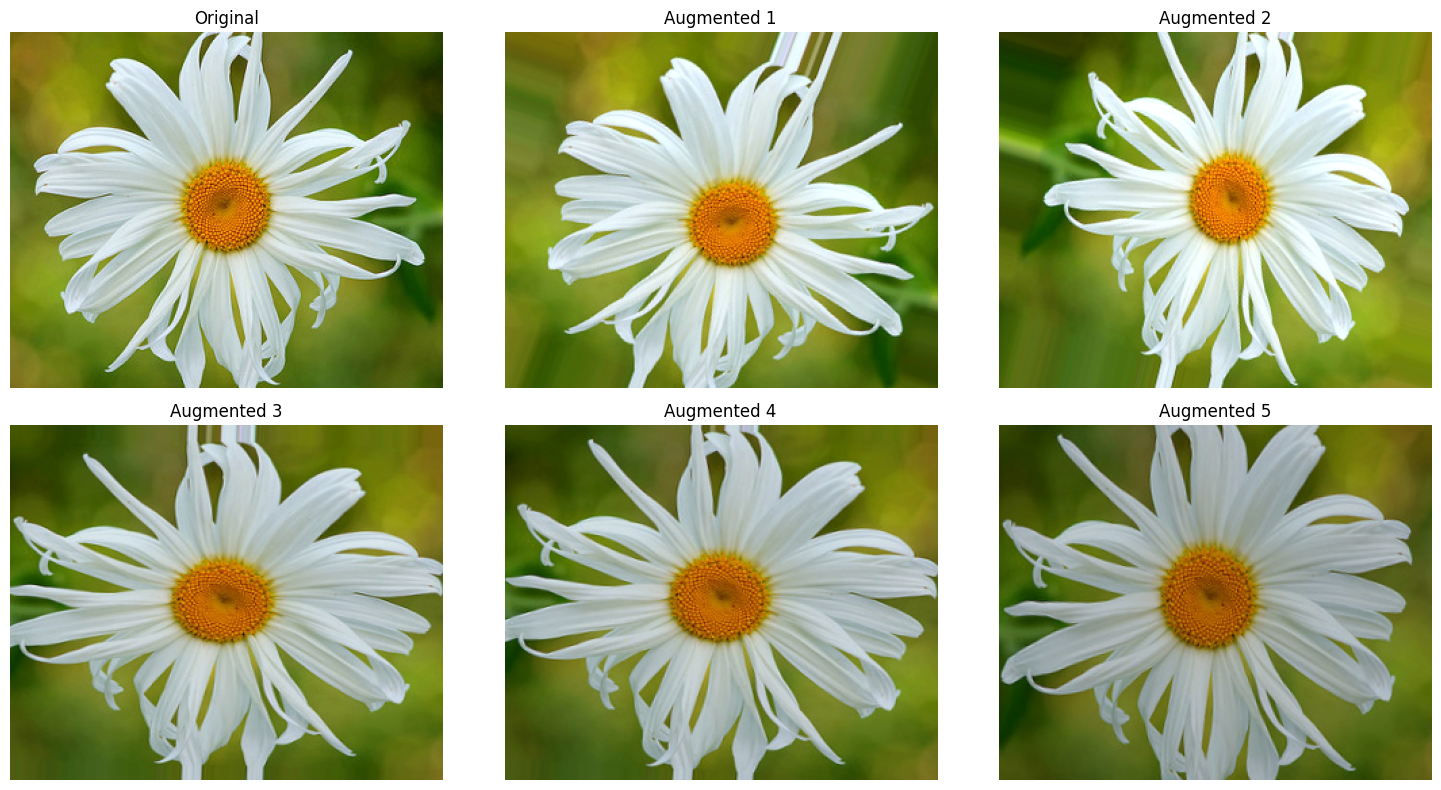

In [16]:
# Read the original image
original_image = cv2.imread(image_path)

# Convert BGR to RGB
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# Add a batch dimension
image_batch = np.expand_dims(original_image, axis=0)

# Generate augmented images
augmented_images = augmentation.flow(
    image_batch,
    batch_size=1,
    shuffle=False
)

# Display the original image and augmented versions
plt.figure(figsize=(15, 8))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

# Augmented images
for i in range(5):
    augmented_image = next(augmented_images)[0].astype(np.uint8)

    plt.subplot(2, 3, i + 2)
    plt.imshow(augmented_image)
    plt.title(f"Augmented {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

##  Augmentation Observations

The augmentation pipeline generated different variations of the
same training image.

The applied transformations changed the appearance of the image
while preserving its main visual content.

This can help the model learn more robust features and reduce
overfitting during training.

The augmentation techniques used were:

- Rotation
- Zoom
- Horizontal flipping
- Brightness adjustment

##  Transfer Learning Preprocessing

When using a pretrained model, image preprocessing should match
the preprocessing expected by that model.

Different pretrained models may expect different input ranges
and preprocessing methods.

For this example, we will use **MobileNetV2** and its
`preprocess_input` function.

MobileNetV2 expects images to be preprocessed before they are
passed to the model.

In [17]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Convert the processed image back to the range expected
# by MobileNetV2
image_for_model = processed_image * 255.0

# Apply MobileNetV2 preprocessing
mobilenet_image = preprocess_input(image_for_model)

print("Shape:", mobilenet_image.shape)
print("Data type:", mobilenet_image.dtype)
print("Minimum value:", mobilenet_image.min())
print("Maximum value:", mobilenet_image.max())

Shape: (224, 224, 3)
Data type: float32
Minimum value: -1.0
Maximum value: 1.0


##  Comparing Preprocessing Methods

We previously normalized the image to the range **0 to 1**.

MobileNetV2 uses a model-specific preprocessing function that converts
the input range to approximately **-1 to 1**.

This demonstrates why we should always check the preprocessing
requirements of a pretrained model before using it.

In [18]:
print("Standard Normalization")
print("---------------------")
print("Shape:", processed_image.shape)
print("Range:", processed_image.min(), "to", processed_image.max())

print("\nMobileNetV2 Preprocessing")
print("------------------------")
print("Shape:", mobilenet_image.shape)
print("Range:", mobilenet_image.min(), "to", mobilenet_image.max())

Standard Normalization
---------------------
Shape: (224, 224, 3)
Range: 0.0 to 1.0

MobileNetV2 Preprocessing
------------------------
Shape: (224, 224, 3)
Range: -1.0 to 1.0


##  Final Preprocessing Pipeline

We will now create a complete preprocessing pipeline for MobileNetV2.

The pipeline will:

1. Read the image using OpenCV.
2. Resize it to 224 × 224.
3. Convert it from BGR to RGB.
4. Convert the pixel values to float32.
5. Apply MobileNetV2-specific preprocessing.

The final output will be ready to be passed to a pretrained MobileNetV2 model.

In [19]:
def mobilenetv2_preprocess(image_path, target_size=(224, 224)):
    # Read image
    image = cv2.imread(image_path)

    # Resize image
    image = cv2.resize(image, target_size)

    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert to float32
    image = image.astype(np.float32)

    # Apply MobileNetV2 preprocessing
    image = preprocess_input(image)

    return image

In [20]:
# Apply the complete preprocessing pipeline
final_image = mobilenetv2_preprocess(image_path)

print("Final image shape:", final_image.shape)
print("Final data type:", final_image.dtype)
print("Final minimum:", final_image.min())
print("Final maximum:", final_image.max())

Final image shape: (224, 224, 3)
Final data type: float32
Final minimum: -1.0
Final maximum: 1.0


##  Preprocessing Pipeline Summary

Throughout this notebook, we built a complete image preprocessing
pipeline using OpenCV and TensorFlow/Keras.

### OpenCV Preprocessing

The main steps were:

1. **Image Reading**
   - Read images using `cv2.imread()`.

2. **Resizing**
   - Resized images to `224 × 224` pixels.

3. **Color Conversion**
   - Converted images from BGR to RGB.

4. **Pixel Normalization**
   - Scaled pixel values from `0–255` to `0–1`.

5. **Data Augmentation**
   - Applied rotation, zoom, horizontal flipping, and brightness changes.

### Transfer Learning Preprocessing

For MobileNetV2, we used the model-specific
`preprocess_input()` function.

The final processed image has:

- Shape: `(224, 224, 3)`
- Data type: `float32`
- Pixel range: `-1 to 1`

This final format is ready to be used as input for a pretrained
MobileNetV2 model.

## Conclusions

In this notebook, I learned how to prepare image data before
feeding it into a deep learning model.

I practiced:

- Reading images with OpenCV.
- Resizing images to a fixed size.
- Handling the BGR and RGB color formats.
- Normalizing pixel values.
- Building a reusable preprocessing function.
- Applying data augmentation.
- Preparing images according to the requirements of a pretrained model.

The preprocessing steps are an important part of a computer vision
pipeline because they ensure that images are provided to the model
in a consistent and appropriate format.